1. Imports & SetUp

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

import joblib

Load & Prepare Data

In [ ]:
# Load the fake/real datasets

fake_df = pd.read_csv("Fake.csv")
true_df = pd.read_csv("True.csv")

fake_df['label'] = 1  # fake
true_df['label'] = 0  # real

# Combine datasets
news_df = pd.concat([fake_df, true_df], ignore_index=True)
# shuffle so model doesn't see fake then real in blocks
news_df = news_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset shape:", news_df.shape)
news_df.head()

Dataset shape: (44898, 5)


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0


3. Prepare Text Columns

In [ ]:
# Combine title + text fields
news_df['content'] = news_df['title'].fillna('') + ' ' + news_df['text'].fillna('')
news_df = news_df[['content', 'label']]

4. Light Text Cleaning

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

news_df['clean_text'] = news_df['content'].apply(clean_text)

5. Classical ML Models

5.1 Split Data

In [ ]:
X = news_df['clean_text']
y = news_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

5.2 Vectorizers

In [ ]:
tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=50000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

5.3 Train ML Models (LR, SVM, Naive Bayes)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced'),
    "Linear SVM": LinearSVC(class_weight='balanced', max_iter=5000),
    "Naive Bayes": MultinomialNB()
}

results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    preds = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, preds)

    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds))

    results.append((name, acc))


Logistic Regression Accuracy: 0.9886
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4284
           1       0.99      0.98      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


Linear SVM Accuracy: 0.9971
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4284
           1       1.00      1.00      1.00      4696

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980


Naive Bayes Accuracy: 0.9524
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      4284
           1       0.95      0.96      0.95      4696

    accuracy                           0.95      8980
   macro avg       0.95      0.

5.4 Plot Comparison

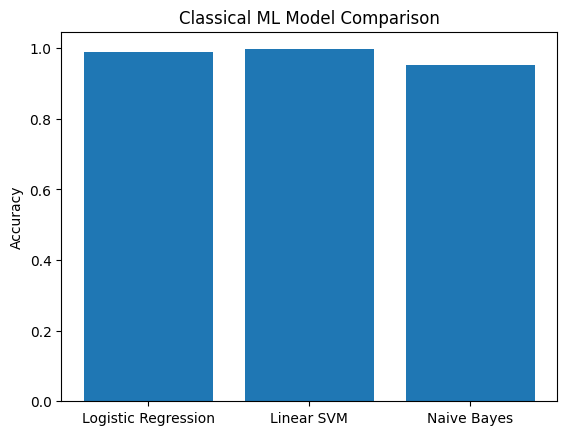

In [ ]:
model_names, acc_values = zip(*results)
plt.bar(model_names, acc_values)
plt.ylabel("Accuracy")
plt.title("Classical ML Model Comparison")
plt.show()

6. Save Best Classical Model (Calibrated SVM)

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

base_svm = LinearSVC(class_weight='balanced')
calib_svm = CalibratedClassifierCV(base_svm, cv=3)

calib_svm.fit(X_train_tfidf, y_train)

joblib.dump(calib_svm, "svm_fake_news_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

7. Prediction Function (Classical Model)

In [ ]:
def predict_news_svm(text):
    clean = clean_text(text)
    vec = tfidf.transform([clean])
    pred = calib_svm.predict(vec)[0]
    prob = calib_svm.predict_proba(vec)[0][pred]
    label = "REAL ✅" if pred == 0 else "FAKE ❌"
    return f"{label} (Confidence: {prob:.2f})"

 Confusion Matrix

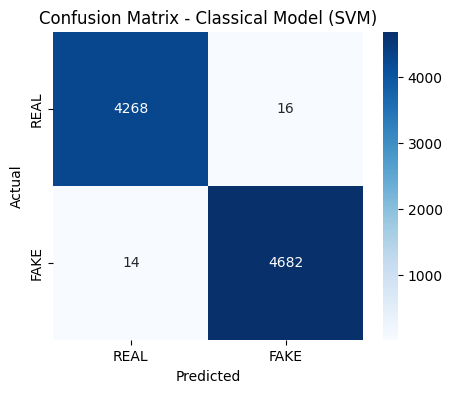

In [ ]:
# Confusion Matrix for Classical Model

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# pick best model (you can change if needed)
best_clf = calib_svm
best_preds = best_clf.predict(X_test_tfidf)

cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["REAL", "FAKE"],
            yticklabels=["REAL", "FAKE"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Classical Model (SVM)")
plt.show()

 Normalized Confusion Matrix

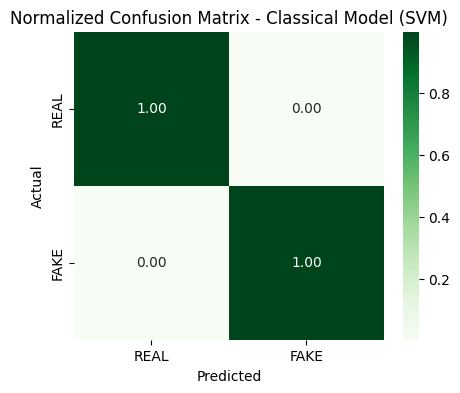

In [ ]:
cm_norm = confusion_matrix(y_test, best_preds, normalize='true')

plt.figure(figsize=(5,4))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=["REAL", "FAKE"],
            yticklabels=["REAL", "FAKE"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Normalized Confusion Matrix - Classical Model (SVM)")
plt.show()

 Text Length Distribution

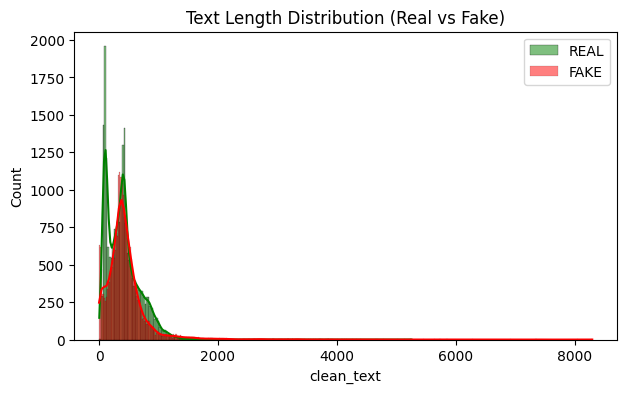

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(news_df[news_df['label']==0]['clean_text'].apply(lambda x: len(x.split())),
             color='green', kde=True, label='REAL')
sns.histplot(news_df[news_df['label']==1]['clean_text'].apply(lambda x: len(x.split())),
             color='red', kde=True, label='FAKE')
plt.legend()
plt.title("Text Length Distribution (Real vs Fake)")
plt.show()

 Word Clouds

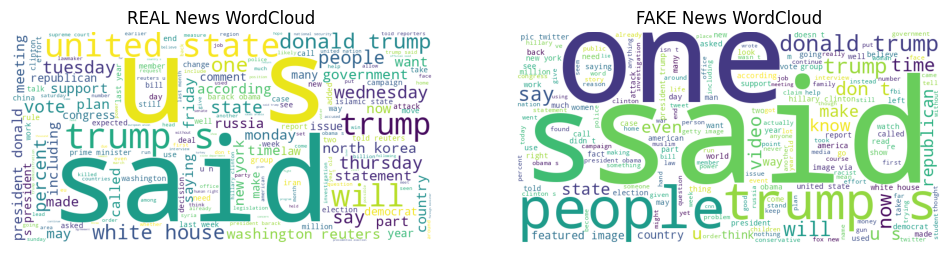

In [ ]:
# WordClouds for Real vs Fake

from wordcloud import WordCloud

real_text = " ".join(news_df[news_df['label']==0]['clean_text'].tolist())
fake_text = " ".join(news_df[news_df['label']==1]['clean_text'].tolist())

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(WordCloud(width=800, height=400, background_color='white').generate(real_text))
plt.title("REAL News WordCloud")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(WordCloud(width=800, height=400, background_color='white').generate(fake_text))
plt.title("FAKE News WordCloud")
plt.axis("off")

plt.show()

In [ ]:
# --- real world demo for the SVM model ---

svm_test_samples = [
    "India launches new satellite for climate monitoring",
    "Government announces new policy for electric vehicles",
    "World will end tomorrow, claims anonymous scientist",
    "Apple reveals official date for its next iPhone event",
    "Doctors find overnight cure for cancer",
]

for t in svm_test_samples:
    print("\nSVM →", t)
    print("Prediction:", predict_news_svm(t))



SVM → India launches new satellite for climate monitoring
Prediction: FAKE ❌ (Confidence: 0.98)

SVM → Government announces new policy for electric vehicles
Prediction: FAKE ❌ (Confidence: 0.89)

SVM → World will end tomorrow, claims anonymous scientist
Prediction: FAKE ❌ (Confidence: 1.00)

SVM → Apple reveals official date for its next iPhone event
Prediction: FAKE ❌ (Confidence: 0.95)

SVM → Doctors find overnight cure for cancer
Prediction: FAKE ❌ (Confidence: 0.93)


8. Demo: User Input + Confidence Score

In [ ]:
user_text = input("Enter a news headline or article snippet: ").strip()

cleaned = clean_text(user_text)
vec = tfidf.transform([cleaned])

pred = calib_svm.predict(vec)[0]
probs = calib_svm.predict_proba(vec)[0]

label = "REAL" if pred == 0 else "FAKE"
confidence = probs[pred]

print("\nPrediction:", label)
print(f"Confidence: {confidence*100:.2f}%")

print("\nClass probabilities:")
print(f"  REAL: {probs[0]*100:.2f}%")
print(f"  FAKE: {probs[1]*100:.2f}%")

Enter a news headline or article snippet: NASA successfully launched a satellite to monitor global weather patterns."

Prediction: FAKE
Confidence: 92.87%

Class probabilities:
  REAL: 7.13%
  FAKE: 92.87%


Level 2: DistilBERT

1. DistilBert Setup

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)

2. Use Raw Text (Not Cleaned)

In [ ]:
df_small = news_df.sample(5000, random_state=42)  # small subset for speed

X_small = df_small['content']
y_small = df_small['label']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_small, y_small, test_size=0.2, random_state=42, stratify=y_small
)

3. Tokenization

In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
max_len = 512

train_enc = tokenizer(list(X_train_b), truncation=True, padding=True, max_length=max_len)
test_enc = tokenizer(list(X_test_b), truncation=True, padding=True, max_length=max_len)

4. Dataset Class

In [ ]:
class NewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(int(self.labels.iloc[idx]))
        return item

    def __len__(self):
        return len(self.labels)

5. Data Loaders

In [ ]:
train_dataset = NewsDataset(train_enc, y_train_b)
test_dataset = NewsDataset(test_enc, y_test_b)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

6. Model, Optimizer, Scheduler

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
).to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

epochs = 2
total_steps = len(train_loader) * epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


7. Training Loop

In [ ]:
# DistilBERT Training (Optimized FP16)

from tqdm.auto import tqdm
import torch

# put model in training mode
model.train()

# GradScaler enables safe mixed-precision on GPU (2–3x faster)
scaler = torch.cuda.amp.GradScaler()

for epoch in range(epochs):
    total_loss = 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=True)

    for batch in progress_bar:
        # move data to GPU
        batch = {k: v.to(device) for k, v in batch.items()}

        optimizer.zero_grad()

        # mixed precision forward pass for speed
        with torch.cuda.amp.autocast():
            outputs = model(**batch)
            loss = outputs.loss

        # backward pass (scaled for FP16 stability)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # update learning rate according to scheduler
        scheduler.step()

        total_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} | Average training loss: {avg_loss:.4f}")

/tmp/ipython-input-4027046703.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Epoch 1:   0%|          | 0/250 [00:00<?, ?it/s]

/tmp/ipython-input-4027046703.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1 | Average training loss: 0.0736


Epoch 2:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch 2 | Average training loss: 0.0050


8. Evaluation

In [ ]:
# DistilBERT Evaluation

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch["labels"].cpu().numpy())

# accuracy & report
print("DistilBERT Accuracy:", accuracy_score(all_labels, all_preds))
print(classification_report(all_labels, all_preds))

DistilBERT Accuracy: 0.999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       479
           1       1.00      1.00      1.00       521

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



9. Save DistilBERT Model

In [ ]:
model.save_pretrained("distilbert_fake_news")
tokenizer.save_pretrained("distilbert_fake_news")

('distilbert_fake_news/tokenizer_config.json',
 'distilbert_fake_news/special_tokens_map.json',
 'distilbert_fake_news/vocab.txt',
 'distilbert_fake_news/added_tokens.json',
 'distilbert_fake_news/tokenizer.json')

In [ ]:
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer
import torch

# Load saved model and tokenizer
model = DistilBertForSequenceClassification.from_pretrained("./distilbert_fake_news")
tokenizer = DistilBertTokenizer.from_pretrained("./distilbert_fake_news")

# Set to evaluation mode
model.eval()



DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


10. DistilBERT Prediction Function

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
def predict_news_bert(text):
    # Tokenize
    enc = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding="max_length",
        max_length=128
    )

    # Move ALL tensors to the correct device
    for k in enc:
        enc[k] = enc[k].to(device)

    # Prediction
    with torch.no_grad():
        outputs = model(**enc)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    label = "REAL ✅" if pred == 0 else "FAKE ❌"
    conf = probs[0][pred].item()
    return f"{label} (Confidence: {conf:.2f})"


In [ ]:
# --- real world demo for the SVM model ---

svm_test_samples = [
    "India launches new satellite for climate monitoring",
    "Government announces new policy for electric vehicles",
    "World will end tomorrow, claims anonymous scientist",
    "Apple reveals official date for its next iPhone event",
    "Doctors find overnight cure for cancer",
]

for t in svm_test_samples:
    print("\nSVM →", t)
    print("Prediction:", predict_news_svm(t))



SVM → India launches new satellite for climate monitoring
Prediction: FAKE ❌ (Confidence: 0.98)

SVM → Government announces new policy for electric vehicles
Prediction: FAKE ❌ (Confidence: 0.89)

SVM → World will end tomorrow, claims anonymous scientist
Prediction: FAKE ❌ (Confidence: 1.00)

SVM → Apple reveals official date for its next iPhone event
Prediction: FAKE ❌ (Confidence: 0.95)

SVM → Doctors find overnight cure for cancer
Prediction: FAKE ❌ (Confidence: 0.93)


In [ ]:
# ---- Real-life testing for DistilBERT ----

bert_test_samples = [
    "India launches new satellite to monitor climate patterns",
    "Government approves new policy for renewable energy expansion",
    "Apple officially confirms the iPhone 16 launch event next month",
    "Scientists discover a way to reverse aging in humans",
    "World will end next week, claims anonymous scientist on social media",
]

for text in bert_test_samples:
    print("\nBERT →", text)
    print("Prediction:", predict_news_bert(text))



BERT → India launches new satellite to monitor climate patterns
Prediction: REAL ✅ (Confidence: 0.75)

BERT → Government approves new policy for renewable energy expansion
Prediction: FAKE ❌ (Confidence: 0.70)

BERT → Apple officially confirms the iPhone 16 launch event next month
Prediction: FAKE ❌ (Confidence: 0.65)

BERT → Scientists discover a way to reverse aging in humans
Prediction: FAKE ❌ (Confidence: 0.85)

BERT → World will end next week, claims anonymous scientist on social media
Prediction: FAKE ❌ (Confidence: 0.99)


In [ ]:
# User input demo for fake news detection
user_text = input("Enter a news snippet to check: \n")

# DistilBERT prediction
bert_result = predict_news_bert(user_text)

# SVM prediction
svm_result = predict_news_svm(user_text)

# Display results in a human-friendly way
print("\n=== Fake News Detection Results ===")
print(f"News: {user_text}\n")
print(f"DistilBERT Prediction: {bert_result}")
print(f"SVM Prediction: {svm_result}")

Enter a news snippet to check: 
NASA confirmed the successful deployment of its latest weather monitoring satellite.

=== Fake News Detection Results ===
News: NASA confirmed the successful deployment of its latest weather monitoring satellite.

DistilBERT Prediction: REAL ✅ (Confidence: 0.93)
SVM Prediction: FAKE ❌ (Confidence: 0.99)


Overall, both classical ML and transformer models performed well, but DistilBERT proved to be the most effective approach for fake news detection.

In [ ]:
news_df['label'].value_counts()

,count
label,
1,23481
0,21417


In [ ]:
news_df.sample(5)

,content,label,clean_text
19551,"Aiming to sidestep Apple dispute, Obama makes ...",0,aiming to sidestep apple dispute obama makes c...
42488,"Lawmakers briefed on reported DNC hack, seek i...",0,lawmakers briefed on reported dnc hack seek in...
10344,5-Year-Old Girl Kills Herself After ‘Responsi...,1,year old girl kills herself after responsible ...
19376,"Factbox: Trump on Twitter (Sept 14) - DACA, U....",0,factbox trump on twitter sept daca u s mexico ...
30041,Trump Meets With Russian Officials One Day Af...,1,trump meets with russian officials one day aft...
